# Conformal forecasting for US unemployment and two synthetic processes

This notebook repeats the S&P 500 conformal methodology on three more predictable targets. It uses the same representation rules and the same complete 15-model NeuralForecast screen. The long AR(1) and deterministic sinusoid have constant data-generating processes; their extra length exists only to provide many calibration and test origins.

These are rolling one-step probabilistic forecasts. All three datasets are reserved for this conformal diagnostic rather than the ordinary manual point-forecast batch.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from thesis.data_preparation import load_dataset
from thesis.dl_evaluation import DL_MODEL_NAMES
from thesis.probabilistic_evaluation import (
    DEFAULT_ML_MODELS,
    DEFAULT_PARAMETRIC_CLASSICAL_MODELS,
    adapt_one_step_dl_configs,
    conformalize_selected_models,
    forecast_classical_stage,
    forecast_fixed_dl_stage,
    forecast_ml_stage,
    forecast_parametric_classical_stage,
    plot_interval_forecast,
    save_selection_config,
    score_prediction_frames,
    tune_ml_candidate,
    validate_dl_candidates,
)
from thesis.reporting import (
    dataset_descriptor,
    figure_path,
    metadata_for,
    publication_latex,
    save_matplotlib_figure,
)

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision('high')

## Controls

US unemployment compares Original and AutoStationary representations for classical models, while XGBRandomForest and LightGBM are evaluated only after AutoStationary transformation. The AR(1) is already stationary and remains Original for every candidate. The sinusoid is deterministic and exactly periodic: classical and deep-learning models retain its original target, while tree models use one AutoStationary representation so the period-four component is removed before recursive regression. Context lengths are dataset-specific.

In [ ]:
AR1_PATH = Path('thesis/data/synthetic_ar1_conformal.csv')
SINUSOID_PATH = Path('thesis/data/synthetic_sinusoidal_conformal.csv')
RESULTS_DIR = Path('thesis/results')
DL_CONFIG_DIR = Path('thesis/model_configs/dl')
SELECTION_CONFIG_PATH = Path('thesis/model_configs/predictable_conformal_selection.json')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASETS_TO_RUN = [
    'US unemployment', 'Conformal AR(1)', 'Conformal sinusoid'
]
ML_MODELS = list(DEFAULT_ML_MODELS)
PARAMETRIC_CLASSICAL_MODELS = list(DEFAULT_PARAMETRIC_CLASSICAL_MODELS)
ML_OPTUNA_TRIALS = 25
ML_TIME_SERIES_SPLITS = 3

RUN_DL = True
RUN_SELECTION_SEARCH = False  # frozen point-model choices are reused
RESET_DL_SELECTION = False
REUSE_SAVED_SELECTION = True
REUSE_CONFORMAL_CHECKPOINTS = False
DL_MODELS = list(DL_MODEL_NAMES)
DL_OPTUNA_TRIALS = 4

INTERVAL_LEVEL = 90
ACI_GAMMA = 0.005
SELECTION_METRIC = 'rmse'
SAVE_FIGURES = True
FIGURE_FORMAT = 'jpg'

missing_synthetic_files = [
    path for path in (AR1_PATH, SINUSOID_PATH) if not path.exists()
]
if missing_synthetic_files:
    raise FileNotFoundError(
        f'Missing conformal synthetic files: {missing_synthetic_files}. '
        'Run the long-series conformal-diagnostics cell in '
        'thesis/synthethic_ts_generation.ipynb first.'
    )

## Data and chronological partitions

`load_dataset` is the same data-preparation entry point used by the classical, ML and DL notebooks. The few lines below only map each dataset to the common `unique_id`, `ds`, `date`, and `y` forecasting schema. They do **not** standardize, scale, difference, or stationarize the target; those operations remain model-stage transformations handled by `AutoStationaryTransformer`.

In [4]:
unemployment_raw, unemployment_config = load_dataset('unemployment_us', 'manual')
time_raw = unemployment_config['columns']['time_raw']
target_raw = unemployment_config['columns']['target_raw']
unemployment = (
    unemployment_raw[[target_raw]]
    .reset_index()
    .rename(columns={time_raw: 'date', target_raw: 'y'})
    .dropna(subset=['y'])
    .sort_values('date')
)
unemployment = unemployment[unemployment['date'] <= '2024-12-01'].copy()
expected_months = pd.date_range(
    unemployment['date'].min(), unemployment['date'].max(), freq='MS'
)
missing_months = expected_months.difference(unemployment['date'])
if len(missing_months):
    raise ValueError(f'Unemployment has missing months: {missing_months.tolist()}')
unemployment.insert(0, 'unique_id', unemployment_config['series_name'])
unemployment.insert(1, 'ds', np.arange(len(unemployment), dtype=int))
unemployment = unemployment[['unique_id', 'ds', 'date', 'y']].reset_index(drop=True)

ar1_raw = pd.read_csv(AR1_PATH).sort_values('time').reset_index(drop=True)
legacy_columns = {'innovation_scale', 'regime'}.intersection(ar1_raw.columns)
if legacy_columns:
    raise ValueError(
        'This is the superseded variance-shift AR(1) file. Rerun the corrected '
        'long conformal AR(1) generator cell before this notebook.'
    )
required_ar1_columns = {'time', 'value', 'phi', 'innovation_sigma'}
if len(ar1_raw) != 6000 or not required_ar1_columns.issubset(ar1_raw.columns):
    raise ValueError(
        'The conformal AR(1) file must contain 6000 rows plus explicit DGP '
        'metadata. Rerun its generator cell.'
    )
if not np.allclose(ar1_raw['phi'], 0.5) or not np.allclose(ar1_raw['innovation_sigma'], 1.0):
    raise ValueError('The conformal AR(1) must use phi=0.5 and innovation sigma=1')
ar1 = pd.DataFrame({
    'unique_id': 'AR1_CONFORMAL',
    'ds': ar1_raw['time'].astype(int),
    'date': ar1_raw['time'].astype(int),
    'y': pd.to_numeric(ar1_raw['value'], errors='raise'),
})

sinusoidal_raw = pd.read_csv(SINUSOID_PATH).sort_values('time').reset_index(drop=True)
required_sinusoid_columns = {
    'time', 'signal_time', 'value', 'amplitude', 'frequency',
    'innovation_sigma'
}
if len(sinusoidal_raw) != 6000 or not required_sinusoid_columns.issubset(sinusoidal_raw.columns):
    raise ValueError(
        'The conformal sinusoid file must contain 6000 rows, its TimeSynth '
        'sampling grid, and explicit DGP metadata. Rerun its generator cell.'
    )
if (
    not np.allclose(sinusoidal_raw['amplitude'], 1.0)
    or not np.allclose(sinusoidal_raw['frequency'], 0.25)
    or not np.allclose(sinusoidal_raw['innovation_sigma'], 0.0)
):
    raise ValueError(
        'The conformal sinusoid must use amplitude=1, frequency=0.25, and no innovation'
    )
if (
    not np.array_equal(sinusoidal_raw['time'].to_numpy(), np.arange(6000))
    or not np.allclose(
        sinusoidal_raw['signal_time'].to_numpy(), np.linspace(0, 1200, 6000)
    )
):
    raise ValueError(
        'The conformal sinusoid must follow the Chapter 1 TimeSynth grid: '
        '6000 observations sampled regularly over signal time 0,...,1200'
    )
sinusoidal = pd.DataFrame({
    'unique_id': 'SINUSOIDAL_CONFORMAL',
    'ds': sinusoidal_raw['time'].astype(int),
    'date': sinusoidal_raw['time'].astype(int),
    'y': pd.to_numeric(sinusoidal_raw['value'], errors='raise'),
})

dataset_partitions = {
    'US unemployment': {
        'train': unemployment[unemployment['date'] < '2010-01-01'],
        'selection': unemployment[unemployment['date'].between('2010-01-01', '2014-12-01')],
        'calibration': unemployment[unemployment['date'].between('2015-01-01', '2019-12-01')],
        'test': unemployment[unemployment['date'].between('2020-01-01', '2024-12-01')],
    },
    'Conformal AR(1)': {
        'train': ar1[ar1['ds'] < 4000],
        'selection': ar1[ar1['ds'].between(4000, 4499)],
        'calibration': ar1[ar1['ds'].between(4500, 4999)],
        'test': ar1[ar1['ds'].between(5000, 5999)],
    },
    'Conformal sinusoid': {
        'train': sinusoidal[sinusoidal['ds'] < 4000],
        'selection': sinusoidal[sinusoidal['ds'].between(4000, 4499)],
        'calibration': sinusoidal[sinusoidal['ds'].between(4500, 4999)],
        'test': sinusoidal[sinusoidal['ds'].between(5000, 5999)],
    },
}
dataset_partitions = {
    dataset: {stage: frame.reset_index(drop=True) for stage, frame in parts.items()}
    for dataset, parts in dataset_partitions.items() if dataset in DATASETS_TO_RUN
}

dataset_settings = {
    'US unemployment': {
        'classical_transformations': ['Original', 'AutoStationary'],
        'ml_transformations': ['AutoStationary'],
        'seasonality': 12,
        'lags': list(range(1, 13)) + [24],
        'dl_input_sizes': [12, 24, 36, 48],
        'dl_internal_val_size': 12,
        'dl_max_steps': 1000,
        'classical': ['HistoricAverage', 'Naive', 'SeasonalNaive'],
        'benchmark': 'SeasonalNaive',
        'metadata_key': 'unemployment_us',
        'plot_tail': 60,
    },
    'Conformal AR(1)': {
        'classical_transformations': ['Original'],
        'ml_transformations': [],
        'seasonality': 1,
        'lags': [1, 2, 3, 5, 10],
        'dl_input_sizes': [10, 20, 40],
        'dl_internal_val_size': 10,
        'dl_max_steps': 1000,
        'classical': ['HistoricAverage', 'Naive', 'AR1OLS'],
        'benchmark': 'AR1OLS',
        'metadata_key': 'ar1_conformal',
        'plot_tail': 250,
    },
    'Conformal sinusoid': {
        'classical_transformations': ['Original'],
        'ml_transformations': ['AutoStationary'],
        'seasonality': 20,
        'lags': list(range(1, 21)) + [40],
        'dl_input_sizes': [20, 40, 60, 80],
        'dl_internal_val_size': 20,
        'dl_max_steps': 1000,
        'classical': ['HistoricAverage', 'Naive', 'SeasonalNaive'],
        'benchmark': 'SeasonalNaive',
        'metadata_key': 'sinusoidal_conformal',
        'plot_tail': 80,
    },
}

partition_rows = []
for dataset, parts in dataset_partitions.items():
    for stage, frame in parts.items():
        if frame.empty:
            raise ValueError(f'{dataset}: empty {stage} partition')
        partition_rows.append({
            'Dataset': dataset, 'Stage': stage, 'Observations': len(frame),
            'First': frame['date'].iloc[0], 'Last': frame['date'].iloc[-1],
        })
display(pd.DataFrame(partition_rows))

,Dataset,Stage,Observations,First,Last
0,US unemployment,train,744,1948-01-01 00:00:00,2009-12-01 00:00:00
1,US unemployment,selection,60,2010-01-01 00:00:00,2014-12-01 00:00:00
2,US unemployment,calibration,60,2015-01-01 00:00:00,2019-12-01 00:00:00
3,US unemployment,test,60,2020-01-01 00:00:00,2024-12-01 00:00:00
4,Conformal AR(1),train,4000,0,3999
5,Conformal AR(1),selection,500,4000,4499
6,Conformal AR(1),calibration,500,4500,4999
7,Conformal AR(1),test,1000,5000,5999
8,Conformal sinusoid,train,4000,0,3999
9,Conformal sinusoid,selection,500,4000,4499


## 1. External point-model selection: classical and ML

Original and AutoStationary unemployment candidates are ranked separately; the stable AR(1) uses Original only. The deterministic period-four sinusoid uses Original for classical and deep-learning candidates and AutoStationary for its tree candidates. XGBRandomForest and LightGBM receive the same 10-trial, three-fold expanding-window Optuna procedure used in the S&P 500 ACI exercise; every transformed fold refits AutoStationary only on that fold's fitting history. If AutoStationary proposes a training-minimum AddM shift followed by Box–Cox, that pair is omitted for out-of-sample use: an unseen value can fall below the training minimum, while enlarging the shift from validation data would leak information. Any fitted detrending and deseasonalization remain active and invertible. Monthly unemployment and the period-four sinusoid also use AutoETS, AutoARIMA, and AutoTheta. For the non-seasonal AR(1), an expanding OLS AR(1) supplies the correctly specified classical autoregression because the installed StatsForecast automatic models do not expose a stable `forward` path for hundreds of season-length-one origins.

In [5]:
selection_frames_by_dataset = {}
candidate_registry_by_dataset = {}
selection_runtime_rows = []

if not RUN_SELECTION_SEARCH:
    if not REUSE_SAVED_SELECTION or not SELECTION_CONFIG_PATH.exists():
        raise FileNotFoundError(
            'Frozen point-model selection is unavailable; set '
            'RUN_SELECTION_SEARCH=True to create it.'
        )
    selection_payload = json.loads(
        SELECTION_CONFIG_PATH.read_text(encoding='utf-8')
    )
    if (
        int(selection_payload.get('seed', -1)) != SEED
        or selection_payload.get('selection_metric') != SELECTION_METRIC
        or int(selection_payload.get('interval_level', -1)) != INTERVAL_LEVEL
        or float(selection_payload.get('aci_gamma', -1)) != ACI_GAMMA
    ):
        raise ValueError('Frozen point-model selection settings do not match')
    representation_winners = selection_payload['selected_classical_ml']
    classical_ml_selection_metrics = pd.read_csv(
        RESULTS_DIR / 'predictable_conformal_point_selection.csv'
    )

for dataset, parts in (
    dataset_partitions.items() if RUN_SELECTION_SEARCH else []
):
    setting = dataset_settings[dataset]
    selection_frames = []
    registry = {}
    for transformation in setting['classical_transformations']:
        for model_name in setting['classical']:
            frame = forecast_classical_stage(
                parts['train'], parts['selection'], model_name, transformation,
                seasonal_period=setting['seasonality'],
            )
            selection_frames.append(frame)
            registry[frame['Model'].iloc[0]] = {
                'family': 'Classical', 'model_name': model_name,
                'transformation': transformation, 'params': {},
            }

        if dataset != 'Conformal AR(1)':
            for model_name in PARAMETRIC_CLASSICAL_MODELS:
                print(f'{dataset}: running {model_name} on {transformation}...')
                frame, stage_seconds = forecast_parametric_classical_stage(
                    parts['train'], parts['selection'], model_name, transformation,
                    season_length=setting['seasonality'],
                )
                selection_frames.append(frame)
                registry[frame['Model'].iloc[0]] = {
                    'family': 'Parametric Classical', 'model_name': model_name,
                    'transformation': transformation,
                    'params': {'season_length': setting['seasonality']},
                }
                selection_runtime_rows.append({
                    'Dataset': dataset, 'Model': frame['Model'].iloc[0],
                    'Stage': 'classical validation', 'Seconds': stage_seconds,
                })

    for transformation in setting['ml_transformations']:
        for model_name in ML_MODELS:
            print(f'{dataset}: tuning {model_name} on {transformation}...')
            params, tuning_seconds = tune_ml_candidate(
                parts['train'], model_name, transformation, setting['lags'],
                ML_OPTUNA_TRIALS, SEED, ML_TIME_SERIES_SPLITS,
                seasonal_period=setting['seasonality'],
            )
            frame, stage_seconds = forecast_ml_stage(
                parts['train'], parts['selection'], model_name, transformation,
                params, setting['lags'], SEED,
                seasonal_period=setting['seasonality'],
            )
            selection_frames.append(frame)
            registry[frame['Model'].iloc[0]] = {
                'family': 'ML', 'model_name': model_name,
                'transformation': transformation, 'params': params,
            }
            selection_runtime_rows.append({
                'Dataset': dataset, 'Model': frame['Model'].iloc[0],
                'Stage': 'ML tuning + validation',
                'Seconds': tuning_seconds + stage_seconds,
            })
    selection_frames_by_dataset[dataset] = selection_frames
    candidate_registry_by_dataset[dataset] = registry

if RUN_SELECTION_SEARCH:
    representation_winners = {}
classical_ml_metrics = []
for dataset, frames in selection_frames_by_dataset.items():
    metrics = score_prediction_frames(frames)
    metrics.insert(0, 'Dataset', dataset)
    classical_ml_metrics.append(metrics)
    representation_winners[dataset] = {}
    representations = list(dict.fromkeys(
        dataset_settings[dataset]['classical_transformations']
        + dataset_settings[dataset]['ml_transformations']
    ))
    for transformation in representations:
        eligible = metrics[
            metrics['Target Transformation'] == transformation
        ].sort_values(SELECTION_METRIC)
        winner_label = eligible.iloc[0]['Model']
        winner = candidate_registry_by_dataset[dataset][winner_label].copy()
        winner['label'] = winner_label
        representation_winners[dataset][transformation] = winner
        print(
            f'{dataset} / {transformation} winner: {winner_label} | '
            f'RMSE={eligible.iloc[0][SELECTION_METRIC]:.6f}'
        )

if RUN_SELECTION_SEARCH:
    classical_ml_selection_metrics = pd.concat(
        classical_ml_metrics, ignore_index=True
    )
display(classical_ml_selection_metrics)
display(pd.DataFrame(selection_runtime_rows))

,Dataset,Model,Base Model,Target Transformation,mae,mse,rmse,selection_tuning_and_fit_seconds,Status,Error
0,US unemployment,AutoARIMA,AutoARIMA,Original,0.119576,0.023414,0.153017,NaN,NaN,NaN
1,US unemployment,AutoARIMA_AutoStationary,AutoARIMA,AutoStationary,0.119683,0.023494,0.153279,NaN,NaN,NaN
2,US unemployment,Naive,Naive,Original,0.125000,0.029500,0.171756,NaN,NaN,NaN
3,US unemployment,Naive_AutoStationary,Naive,AutoStationary,0.126209,0.029793,0.172606,NaN,NaN,NaN
4,US unemployment,AutoTheta_AutoStationary,AutoTheta,AutoStationary,0.129635,0.030673,0.175138,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
65,Conformal sinusoid,AutoTSMixer,AutoTSMixer,Original,0.006615,0.000082,0.009049,89.644609,Completed,NaN
66,Conformal sinusoid,AutoPatchTST,AutoPatchTST,Original,0.007325,0.000086,0.009258,107.058441,Completed,NaN
67,Conformal sinusoid,AutoTimesNet,AutoTimesNet,Original,0.008040,0.000143,0.011974,156.152395,Completed,NaN
68,Conformal sinusoid,AutoiTransformer,AutoiTransformer,Original,0.029804,0.001036,0.032188,71.971159,Completed,NaN


""


## 2. External point-model selection: DL

All 15 Auto architectures are tuned separately for each dataset using the dataset-specific context lengths and the same four-trial Optuna budget as `dl_models.ipynb`. Deep-learning targets are not AutoStationary-transformed. The cell is resumable within the same kernel: successful architectures are retained and only pending or failed candidates rerun.

In [6]:
if RUN_DL and RUN_SELECTION_SEARCH:
    if RESET_DL_SELECTION or 'dl_state_by_dataset' not in globals():
        dl_state_by_dataset = {}

    for dataset, parts in dataset_partitions.items():
        setting = dataset_settings[dataset]
        state = dl_state_by_dataset.setdefault(dataset, {
            'frames': [], 'metrics': pd.DataFrame(), 'resolved': {},
        })
        configs = adapt_one_step_dl_configs(
            DL_CONFIG_DIR, DL_MODELS, setting['dl_input_sizes'],
            DL_OPTUNA_TRIALS, setting['dl_max_steps'], SEED,
        )
        pending = {
            name: config for name, config in configs.items()
            if name not in state['resolved']
        }
        if pending:
            print(f'{dataset} pending DL candidates: {list(pending)}')
            new_frames, new_metrics, new_resolved = validate_dl_candidates(
                parts['train'], parts['selection'], pending,
                setting['dl_internal_val_size'],
            )
            pending_names = set(pending)
            state['frames'] = [
                frame for frame in state['frames']
                if frame['Model'].iloc[0] not in pending_names
            ] + new_frames
            state['metrics'] = pd.concat(
                [state['metrics'], new_metrics], ignore_index=True
            ).drop_duplicates('Model', keep='last').sort_values(
                SELECTION_METRIC, na_position='last'
            ).reset_index(drop=True)
            state['resolved'].update(new_resolved)
        else:
            print(f'{dataset}: every DL candidate is already completed.')
        display(state['metrics'])

    dl_winners = {}
    for dataset, state in dl_state_by_dataset.items():
        completed = state['metrics'].dropna(subset=[SELECTION_METRIC])
        if completed.empty:
            raise RuntimeError(f'Every DL candidate failed for {dataset}')
        model_name = completed.iloc[0]['Model']
        dl_winners[dataset] = {
            'model_name': model_name,
            'resolved_config': state['resolved'][model_name],
        }
        print(
            f'{dataset} DL winner: {model_name} | '
            f'RMSE={completed.iloc[0][SELECTION_METRIC]:.6f}'
        )
elif RUN_DL:
    dl_winners = selection_payload.get('selected_dl', {})
    missing_dl = set(dataset_partitions) - set(dl_winners)
    if missing_dl:
        raise ValueError(
            f'Frozen DL selection is incomplete for {sorted(missing_dl)}'
        )
else:
    dl_winners = {}

In [7]:
selection_payload = {
    'seed': SEED,
    'selection_metric': SELECTION_METRIC,
    'interval_level': INTERVAL_LEVEL,
    'aci_gamma': ACI_GAMMA,
    'ml_optuna_trials': ML_OPTUNA_TRIALS,
    'ml_time_series_splits': ML_TIME_SERIES_SPLITS,
    'ml_models': ML_MODELS,
    'target_representations': {
        dataset: {
            'classical': setting['classical_transformations'],
            'ml': setting['ml_transformations'],
        }
        for dataset, setting in dataset_settings.items()
    },
    'selected_classical_ml': representation_winners,
    'selected_dl': dl_winners,
}
if RUN_SELECTION_SEARCH:
    save_selection_config(SELECTION_CONFIG_PATH, selection_payload)

all_selection_parts = [classical_ml_selection_metrics]
if RUN_DL and RUN_SELECTION_SEARCH:
    for dataset, state in dl_state_by_dataset.items():
        metrics = state['metrics'].copy()
        metrics.insert(0, 'Dataset', dataset)
        all_selection_parts.append(metrics)
all_selection_metrics = pd.concat(all_selection_parts, ignore_index=True, sort=False)
if RUN_SELECTION_SEARCH:
    all_selection_metrics.to_csv(
        RESULTS_DIR / 'predictable_conformal_point_selection.csv', index=False
    )
display(all_selection_metrics.sort_values(['Dataset', SELECTION_METRIC]))

,Dataset,Model,Base Model,Target Transformation,mae,mse,rmse,selection_tuning_and_fit_seconds,Status,Error
14,Conformal AR(1),AR1OLS,AR1OLS,Original,0.763570,0.953298,0.976370,NaN,NaN,NaN
40,Conformal AR(1),AutoGRU,AutoGRU,Original,0.768552,0.972976,0.986395,74.148797,Completed,NaN
41,Conformal AR(1),AutoLSTM,AutoLSTM,Original,0.773737,0.979171,0.989531,79.024351,Completed,NaN
42,Conformal AR(1),AutoRNN,AutoRNN,Original,0.774794,0.989822,0.994898,69.691581,Completed,NaN
43,Conformal AR(1),AutoPatchTST,AutoPatchTST,Original,0.782150,1.007189,1.003588,86.963815,Completed,NaN
...,...,...,...,...,...,...,...,...,...,...
39,US unemployment,AutoAutoformer,AutoAutoformer,Original,0.475905,0.543524,0.737241,99.167577,Completed,NaN
10,US unemployment,SeasonalNaive,SeasonalNaive,Original,0.818333,0.817500,0.904157,NaN,NaN,NaN
11,US unemployment,SeasonalNaive_AutoStationary,SeasonalNaive,AutoStationary,0.838482,0.848307,0.921036,NaN,NaN,NaN
12,US unemployment,HistoricAverage_AutoStationary,HistoricAverage,AutoStationary,1.669917,3.871726,1.967670,NaN,NaN,NaN


## 3. Separate conformal calibration and untouched test

For each dataset, every applicable representation winner, the DL winner, and an economic/process benchmark are conformalized. Validation-selected configurations are refitted on training plus validation for calibration and on training plus validation plus calibration for test. Test outcomes update ACI only after each interval is issued.

In [8]:
def forecast_selected_non_dl(dataset, spec, fit_df, evaluation_df):
    setting = dataset_settings[dataset]
    if spec['family'] == 'Classical':
        return forecast_classical_stage(
            fit_df, evaluation_df, spec['model_name'], spec['transformation'],
            seasonal_period=setting['seasonality'],
        )
    if spec['family'] == 'Parametric Classical':
        frame, _ = forecast_parametric_classical_stage(
            fit_df, evaluation_df, spec['model_name'], spec['transformation'],
            season_length=setting['seasonality'],
        )
        return frame
    frame, _ = forecast_ml_stage(
        fit_df, evaluation_df, spec['model_name'], spec['transformation'],
        spec['params'], setting['lags'], SEED,
        seasonal_period=setting['seasonality'],
    )
    return frame


all_interval_frames = []
all_interval_metrics = []
all_test_point_metrics = []

if not REUSE_SAVED_SELECTION or not SELECTION_CONFIG_PATH.exists():
    raise RuntimeError('Frozen point-model selection is unavailable.')
selection_payload = json.loads(
    SELECTION_CONFIG_PATH.read_text(encoding='utf-8')
)
if (
    int(selection_payload.get('seed', -1)) != SEED
    or selection_payload.get('selection_metric') != SELECTION_METRIC
    or int(selection_payload.get('interval_level', -1)) != INTERVAL_LEVEL
    or float(selection_payload.get('aci_gamma', -1)) != ACI_GAMMA
):
    raise ValueError('Saved conformal selection settings do not match')
representation_winners = selection_payload['selected_classical_ml']
dl_winners = selection_payload.get('selected_dl', {}) if RUN_DL else {}
print(f'Reloaded frozen winners from {SELECTION_CONFIG_PATH}')

for dataset, parts in dataset_partitions.items():
    checkpoint_slug = dataset.lower().replace('(', '').replace(')', '')
    checkpoint_slug = checkpoint_slug.replace(' ', '_').replace('/', '_')
    interval_checkpoint = RESULTS_DIR / f'{checkpoint_slug}_conformal_intervals.csv'
    interval_metric_checkpoint = RESULTS_DIR / f'{checkpoint_slug}_conformal_metrics.csv'
    point_metric_checkpoint = RESULTS_DIR / f'{checkpoint_slug}_conformal_point_metrics.csv'
    if (
        REUSE_CONFORMAL_CHECKPOINTS
        and interval_checkpoint.exists()
        and interval_metric_checkpoint.exists()
        and point_metric_checkpoint.exists()
    ):
        print(f'{dataset}: loading completed conformal checkpoint.')
        all_interval_frames.append(pd.read_csv(interval_checkpoint))
        all_interval_metrics.append(pd.read_csv(interval_metric_checkpoint))
        all_test_point_metrics.append(pd.read_csv(point_metric_checkpoint))
        continue

    dataset_start = time.perf_counter()
    print(f'[{dataset}] calibration and test forecasting started.')
    calibration_fit = pd.concat(
        [parts['train'], parts['selection']], ignore_index=True
    )
    test_fit = pd.concat(
        [parts['train'], parts['selection'], parts['calibration']], ignore_index=True
    )
    calibration_frames = []
    test_frames = []
    selected_specs = list(representation_winners[dataset].values())
    for spec_index, spec in enumerate(selected_specs, start=1):
        label = spec.get('label', spec['model_name'])
        print(
            f'[{dataset}] non-DL winner {spec_index}/{len(selected_specs)}: '
            f'{label} calibration forecast.'
        )
        calibration_frames.append(forecast_selected_non_dl(
            dataset, spec, calibration_fit, parts['calibration']
        ))
        print(f'[{dataset}] {label}: test forecast.')
        test_frames.append(forecast_selected_non_dl(
            dataset, spec, test_fit, parts['test']
        ))

    if RUN_DL:
        dl_spec = dl_winners[dataset]
        print(f"[{dataset}] DL winner {dl_spec['model_name']}: calibration fit.")
        calibration_dl, _ = forecast_fixed_dl_stage(
            calibration_fit, parts['calibration'], dl_spec['model_name'],
            dl_spec['resolved_config'], SEED,
        )
        print(f"[{dataset}] DL winner {dl_spec['model_name']}: test fit.")
        test_dl, _ = forecast_fixed_dl_stage(
            test_fit, parts['test'], dl_spec['model_name'],
            dl_spec['resolved_config'], SEED,
        )
        calibration_frames.append(calibration_dl)
        test_frames.append(test_dl)

    benchmark = dataset_settings[dataset]['benchmark']
    if not any(
        frame['Base Model'].iloc[0] == benchmark
        and frame['Target Transformation'].iloc[0] == 'Original'
        for frame in calibration_frames
    ):
        print(f'[{dataset}] benchmark {benchmark}: calibration and test.')
        calibration_frames.append(forecast_classical_stage(
            calibration_fit, parts['calibration'], benchmark, 'Original',
            seasonal_period=dataset_settings[dataset]['seasonality'],
        ))
        test_frames.append(forecast_classical_stage(
            test_fit, parts['test'], benchmark, 'Original',
            seasonal_period=dataset_settings[dataset]['seasonality'],
        ))

    test_metrics = score_prediction_frames(test_frames)
    test_metrics.insert(0, 'Dataset', dataset)
    all_test_point_metrics.append(test_metrics)
    intervals, metrics = conformalize_selected_models(
        calibration_frames, test_frames,
        level=INTERVAL_LEVEL, gamma=ACI_GAMMA,
    )
    intervals.insert(0, 'Dataset', dataset)
    metrics.insert(0, 'Dataset', dataset)
    all_interval_frames.append(intervals)
    all_interval_metrics.append(metrics)
    intervals.to_csv(interval_checkpoint, index=False)
    metrics.to_csv(interval_metric_checkpoint, index=False)
    test_metrics.to_csv(point_metric_checkpoint, index=False)
    print(
        f'[{dataset}] checkpoint saved after '
        f'{(time.perf_counter() - dataset_start) / 60:.1f} minutes.'
    )

test_point_metrics = pd.concat(all_test_point_metrics, ignore_index=True)
interval_forecasts = pd.concat(all_interval_frames, ignore_index=True)
interval_metrics = pd.concat(all_interval_metrics, ignore_index=True)
display(test_point_metrics)
display(interval_metrics)

Reloaded frozen winners from thesis\model_configs\predictable_conformal_selection.json
[US unemployment] calibration and test forecasting started.
[US unemployment] non-DL winner 1/2: AutoARIMA calibration forecast.
[US unemployment] AutoARIMA: test forecast.
[US unemployment] non-DL winner 2/2: AutoARIMA_AutoStationary calibration forecast.
[US unemployment] AutoARIMA_AutoStationary: test forecast.
[US unemployment] DL winner AutoVanillaTransformer: calibration fit.
AutoVanillaTransformer: fixed fit plus 60 rolling forecasts started.
AutoVanillaTransformer: fixed fit plus rolling forecasts completed in 31.6s.
[US unemployment] DL winner AutoVanillaTransformer: test fit.
AutoVanillaTransformer: fixed fit plus 60 rolling forecasts started.
AutoVanillaTransformer: fixed fit plus rolling forecasts completed in 33.0s.
[US unemployment] benchmark SeasonalNaive: calibration and test.
[US unemployment] checkpoint saved after 2.1 minutes.
[Conformal AR(1)] calibration and test forecasting star

,Dataset,Model,Base Model,Target Transformation,mae,mse,rmse
0,US unemployment,AutoARIMA_AutoStationary,AutoARIMA,AutoStationary,8.135464e-01,2.830326e+00,1.682357e+00
1,US unemployment,AutoARIMA,AutoARIMA,Original,8.137788e-01,2.830591e+00,1.682436e+00
2,US unemployment,AutoVanillaTransformer,AutoVanillaTransformer,Original,1.247970e+00,7.618349e+00,2.760136e+00
3,US unemployment,SeasonalNaive,SeasonalNaive,Original,2.156667e+00,1.111833e+01,3.334416e+00
4,Conformal AR(1),AR1OLS,AR1OLS,Original,8.214519e-01,1.042156e+00,1.020861e+00
5,Conformal AR(1),AutoGRU,AutoGRU,Original,8.353603e-01,1.077564e+00,1.038058e+00
6,Conformal sinusoid,AutoTiDE,AutoTiDE,Original,3.406245e-08,1.904934e-15,4.364554e-08
7,Conformal sinusoid,AutoARIMA,AutoARIMA,Original,7.186162e-06,6.349289e-11,7.968243e-06
8,Conformal sinusoid,SeasonalNaive,SeasonalNaive,Original,6.638318e-04,5.485839e-07,7.406645e-04
9,Conformal sinusoid,LightGBM_AutoStationary,LightGBM,AutoStationary,8.956851e-03,2.645163e-04,1.626396e-02


,Dataset,Model,Method,Nominal Coverage,Empirical Coverage,Coverage Error,Mean Interval Width,Mean Interval Score,MAE,RMSE,ACI gamma
0,US unemployment,AutoARIMA,Adaptive conformal inference,0.9,0.833333,0.066667,2.917409e+00,1.121194e+01,8.137788e-01,1.682436e+00,0.005
1,US unemployment,AutoARIMA,Split conformal,0.9,0.333333,0.566667,3.957936e-01,1.336734e+01,8.137788e-01,1.682436e+00,NaN
2,US unemployment,AutoARIMA_AutoStationary,Adaptive conformal inference,0.9,0.833333,0.066667,2.918874e+00,1.121028e+01,8.135464e-01,1.682357e+00,0.005
3,US unemployment,AutoARIMA_AutoStationary,Split conformal,0.9,0.350000,0.550000,4.004657e-01,1.333960e+01,8.135464e-01,1.682357e+00,NaN
4,US unemployment,AutoVanillaTransformer,Adaptive conformal inference,0.9,0.866667,0.033333,5.570056e+00,2.083974e+01,1.247970e+00,2.760136e+00,0.005
5,US unemployment,AutoVanillaTransformer,Split conformal,0.9,0.433333,0.466667,3.947891e-01,2.229084e+01,1.247970e+00,2.760136e+00,NaN
6,US unemployment,SeasonalNaive,Adaptive conformal inference,0.9,0.866667,0.033333,8.560000e+00,2.336000e+01,2.156667e+00,3.334416e+00,0.005
7,US unemployment,SeasonalNaive,Split conformal,0.9,0.500000,0.400000,1.800000e+00,3.253333e+01,2.156667e+00,3.334416e+00,NaN
8,Conformal AR(1),AR1OLS,Adaptive conformal inference,0.9,0.898000,0.002000,3.360331e+00,4.171711e+00,8.214519e-01,1.020861e+00,0.005
9,Conformal AR(1),AR1OLS,Split conformal,0.9,0.871000,0.029000,3.162657e+00,4.178790e+00,8.214519e-01,1.020861e+00,NaN


In [9]:
test_point_metrics.to_csv(
    RESULTS_DIR / 'predictable_conformal_test_point_metrics.csv', index=False
)
interval_forecasts.to_csv(
    RESULTS_DIR / 'predictable_conformal_intervals.csv', index=False
)
interval_metrics.to_csv(
    RESULTS_DIR / 'predictable_conformal_metrics.csv', index=False
)
(RESULTS_DIR / 'predictable_conformal_metrics.tex').write_text(
    publication_latex(
        interval_metrics,
        caption=(
            f'{dataset_descriptor("unemployment_us")}; and '
            f'{dataset_descriptor("ar1_conformal")}; and '
            f'{dataset_descriptor("sinusoidal_conformal")}. '
            'Conformal test performance.'
        ),
        label='tab:predictable-series-conformal-results',
        float_format=lambda value: f'{value:.4f}',
    ), encoding='utf-8',
)
print('Conformal outputs exported to thesis/results.')

Conformal outputs exported to thesis/results.


## 4. Forecast intervals and rolling coverage

The plots are shown for every conformalized point model and all three interval methods. Rolling coverage uses 12 origins for unemployment and 50 for each long synthetic process, complementing full-test coverage, width, and interval score.

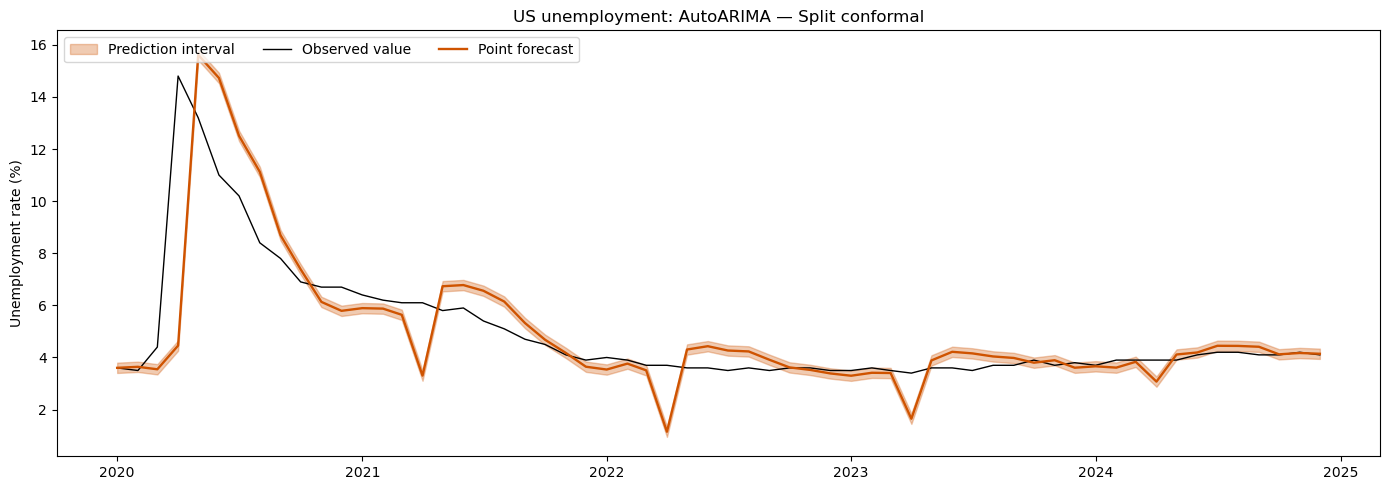

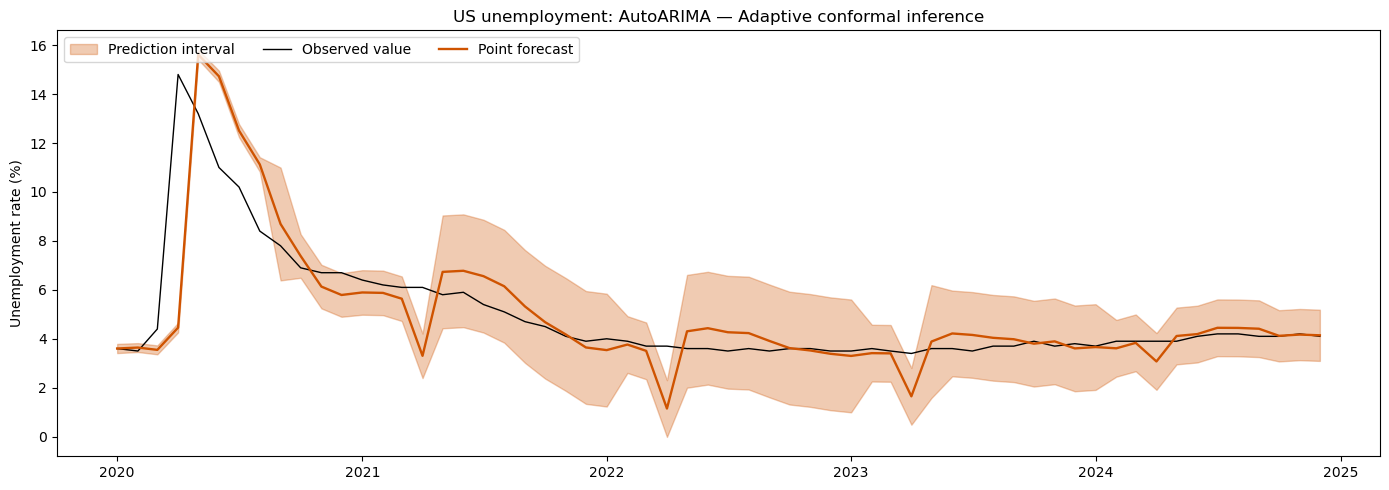

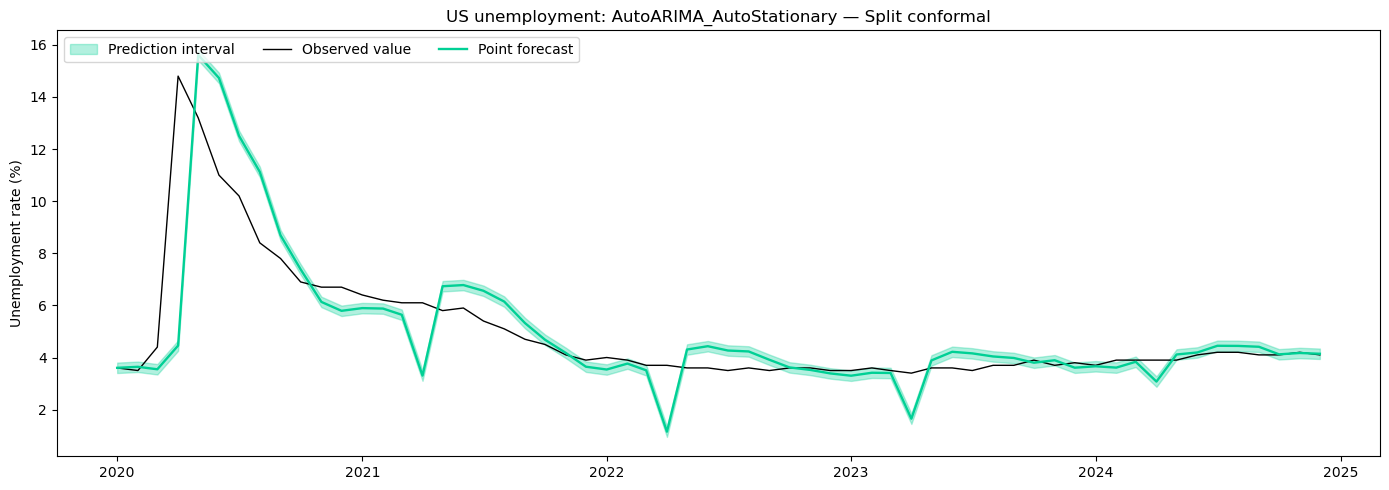

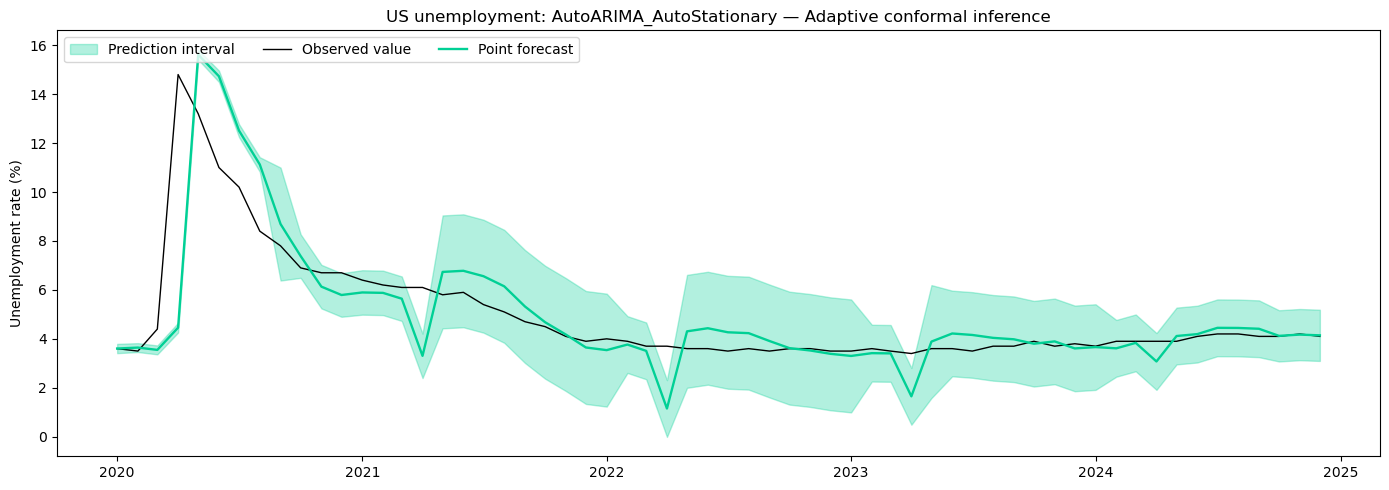

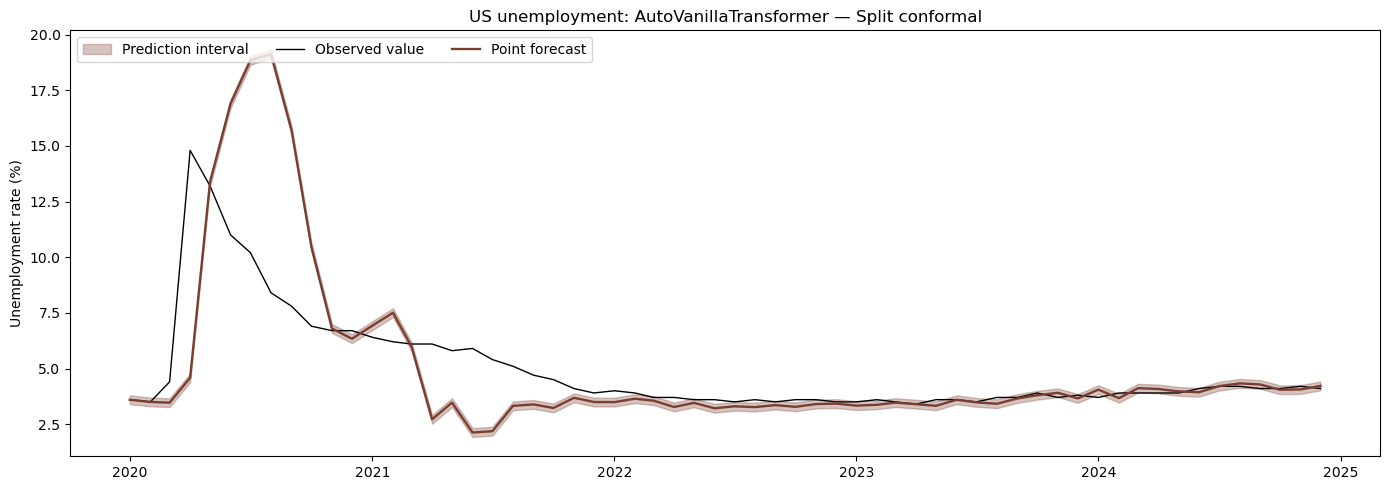

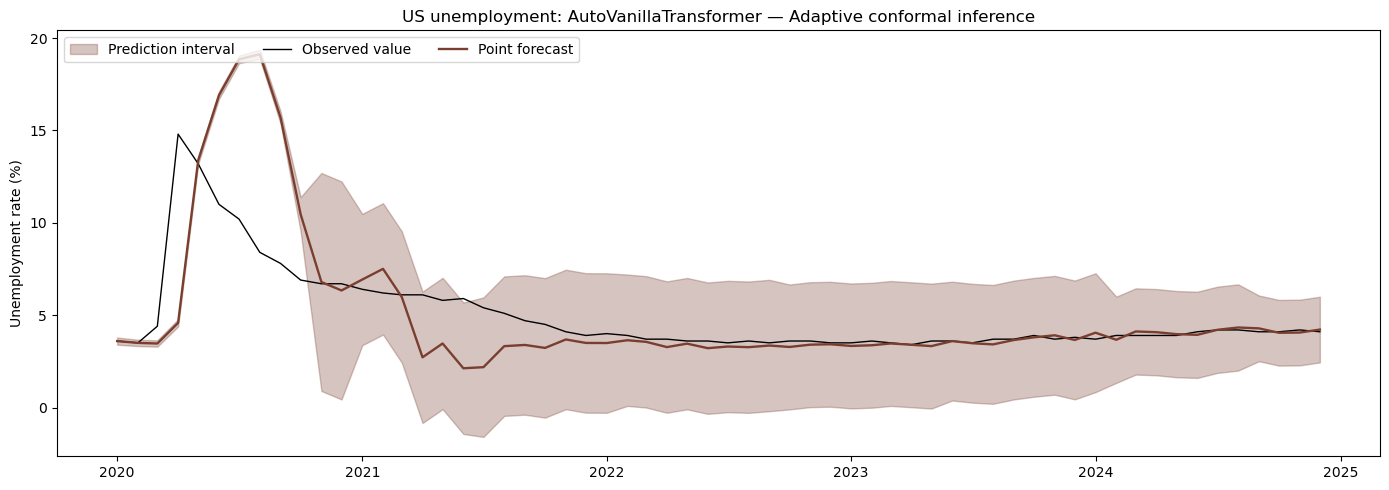

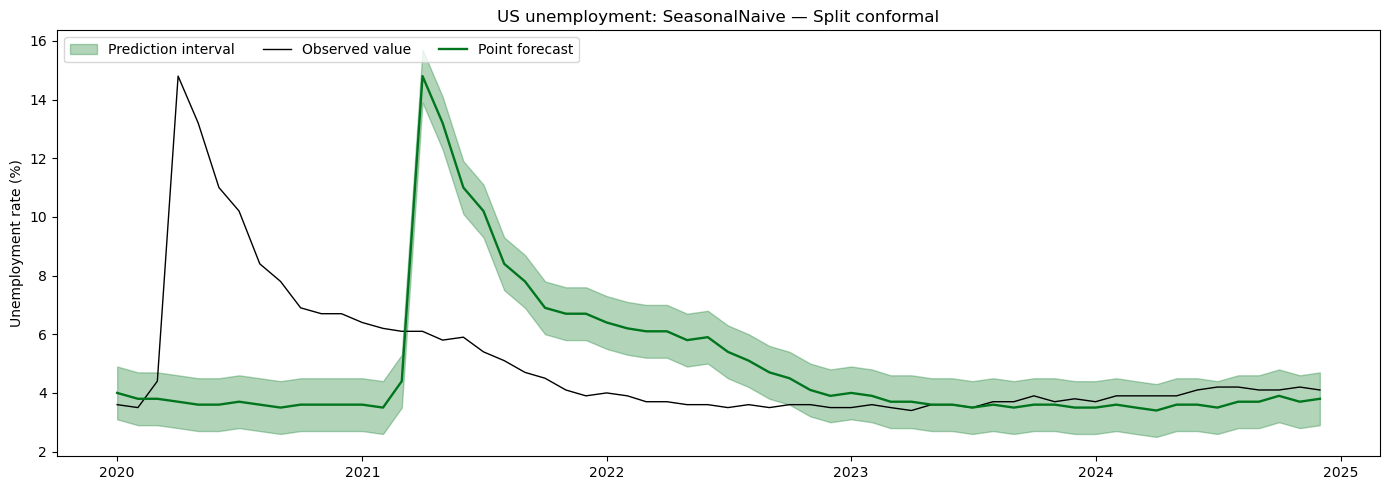

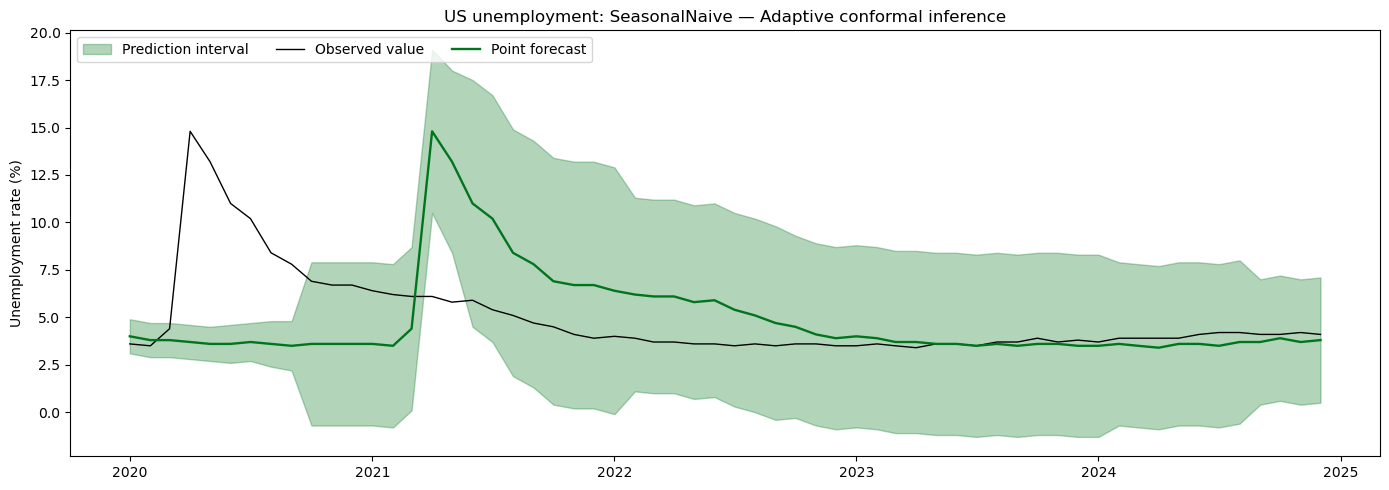

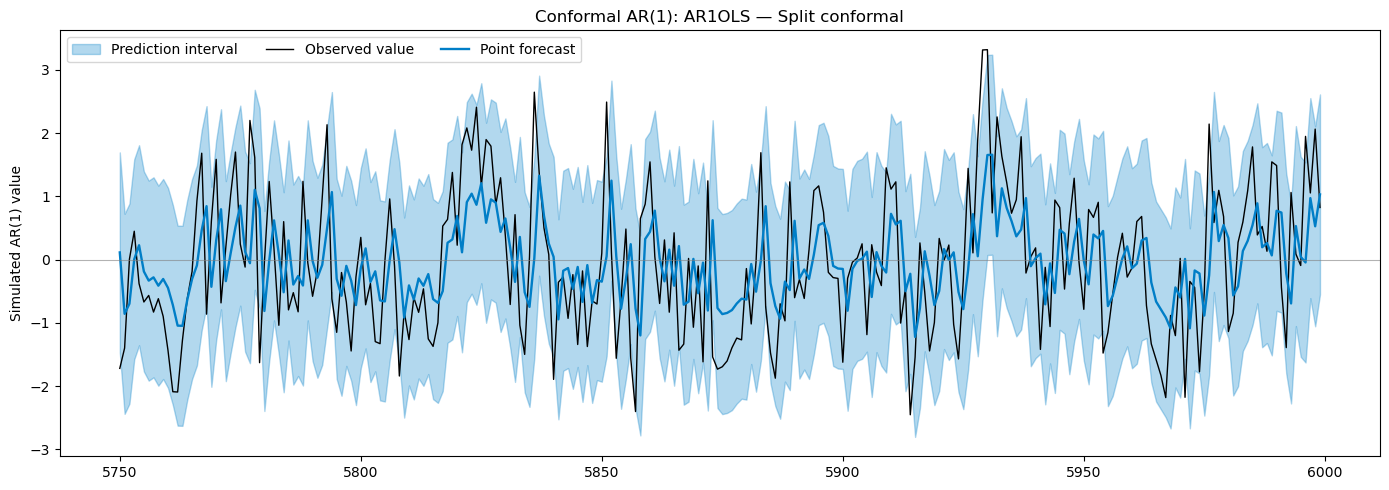

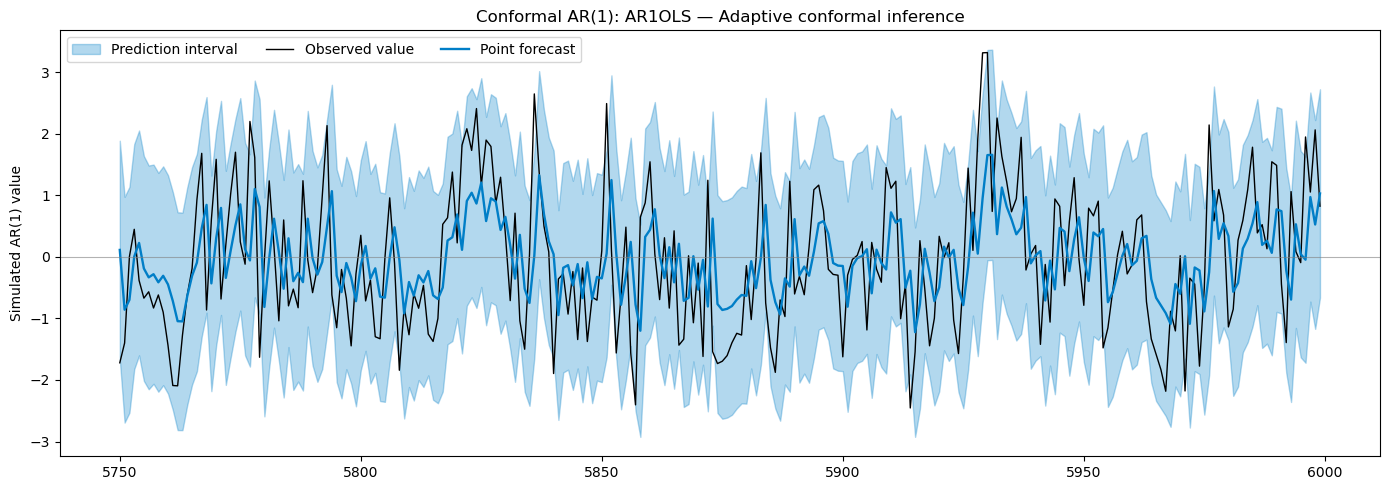

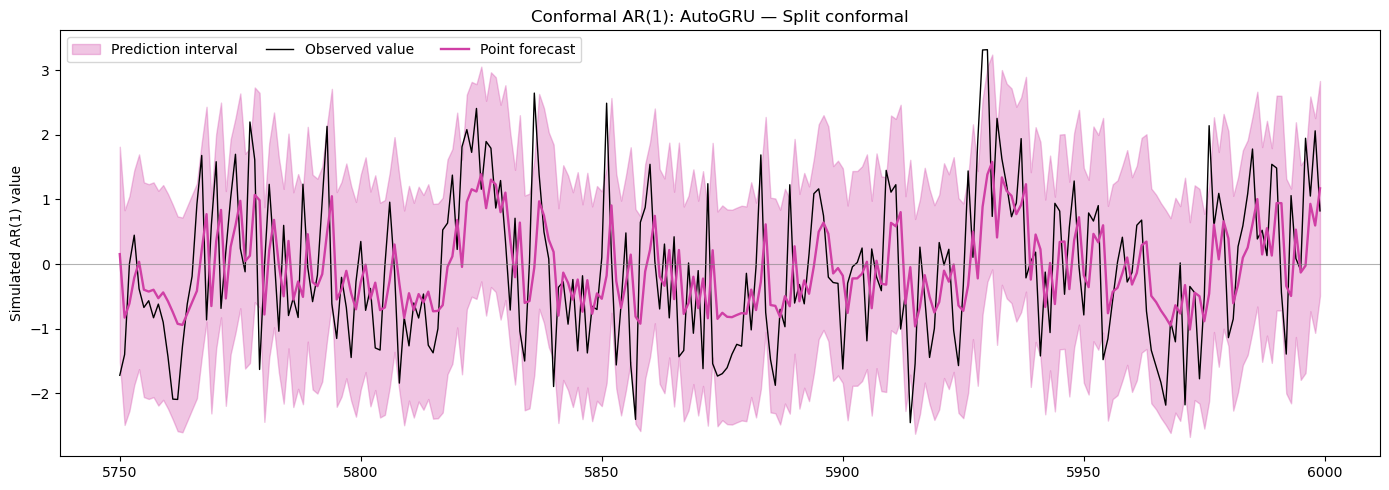

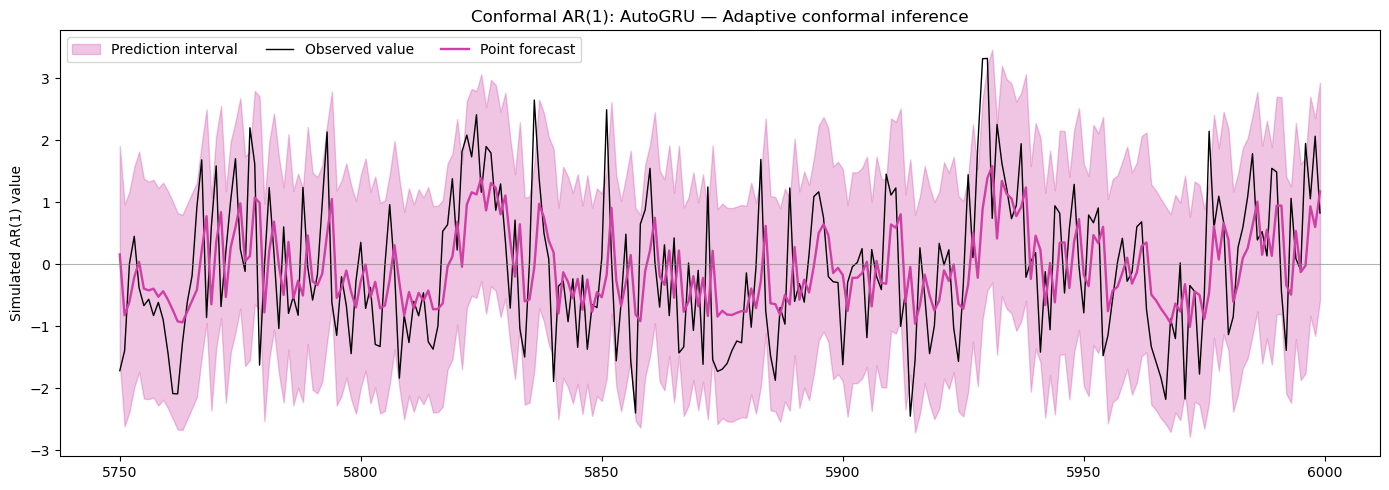

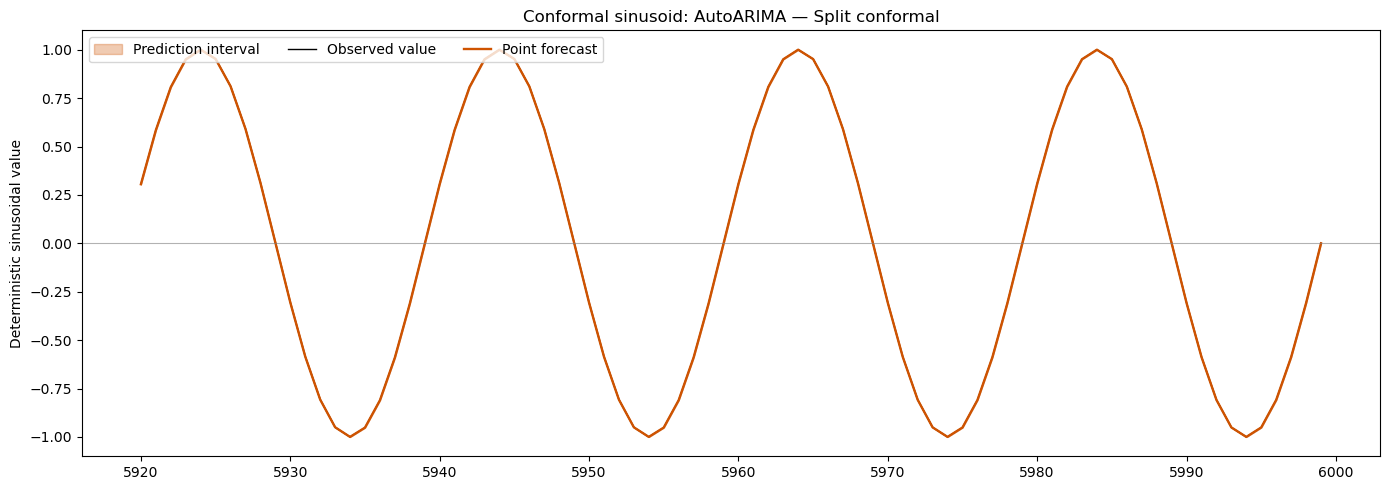

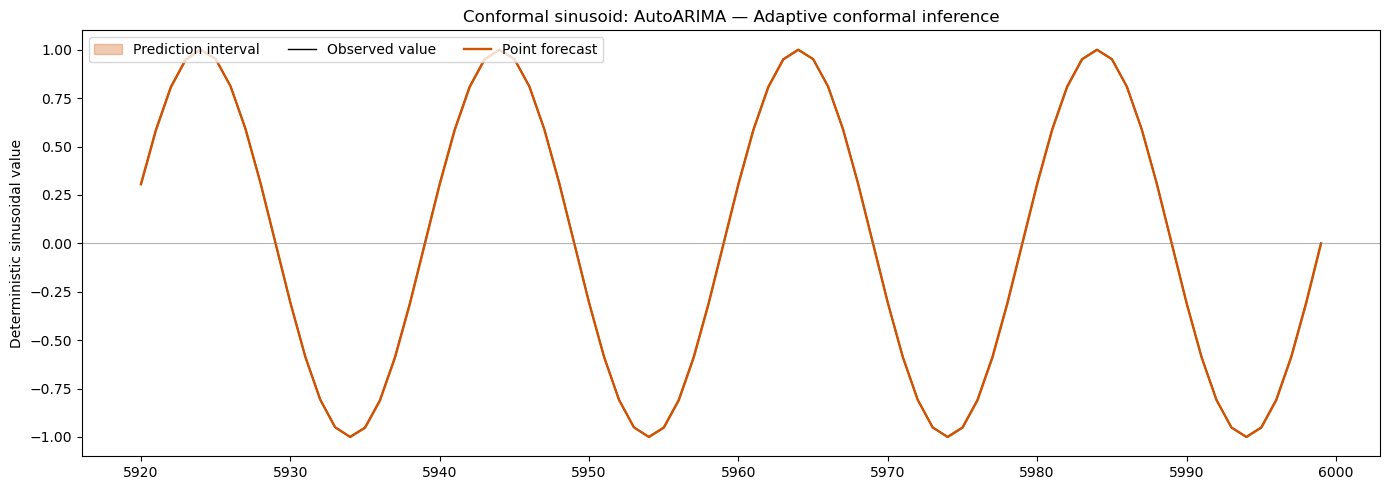

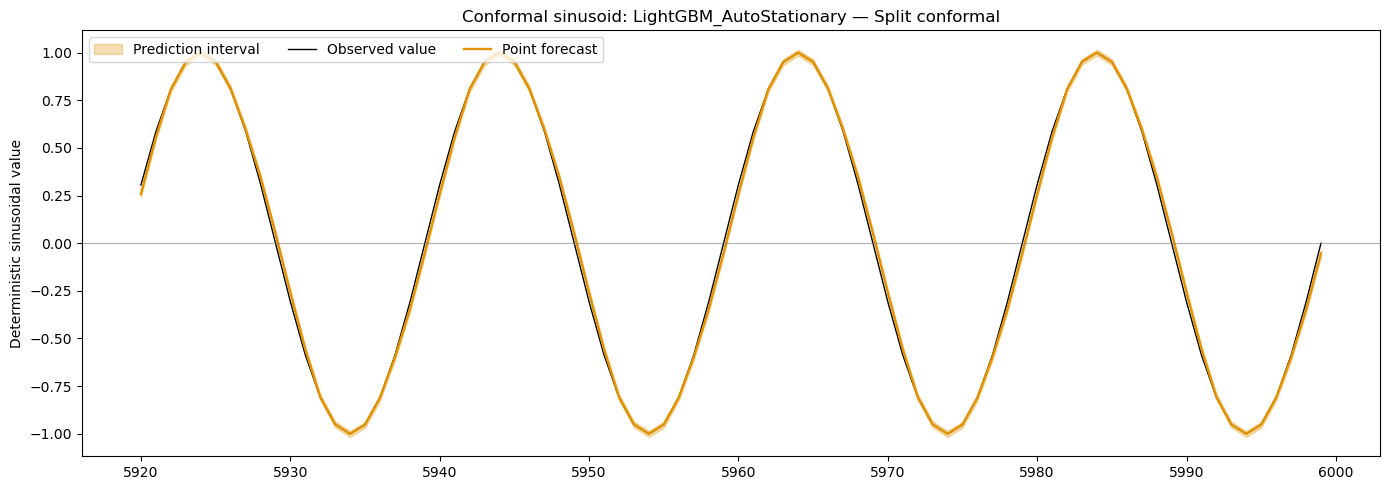

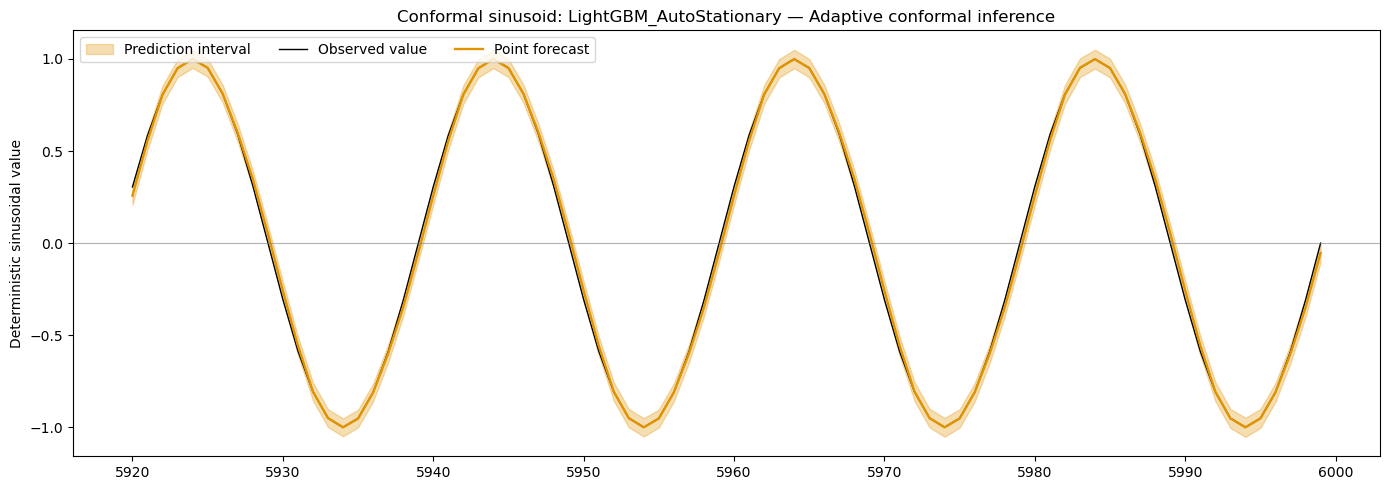

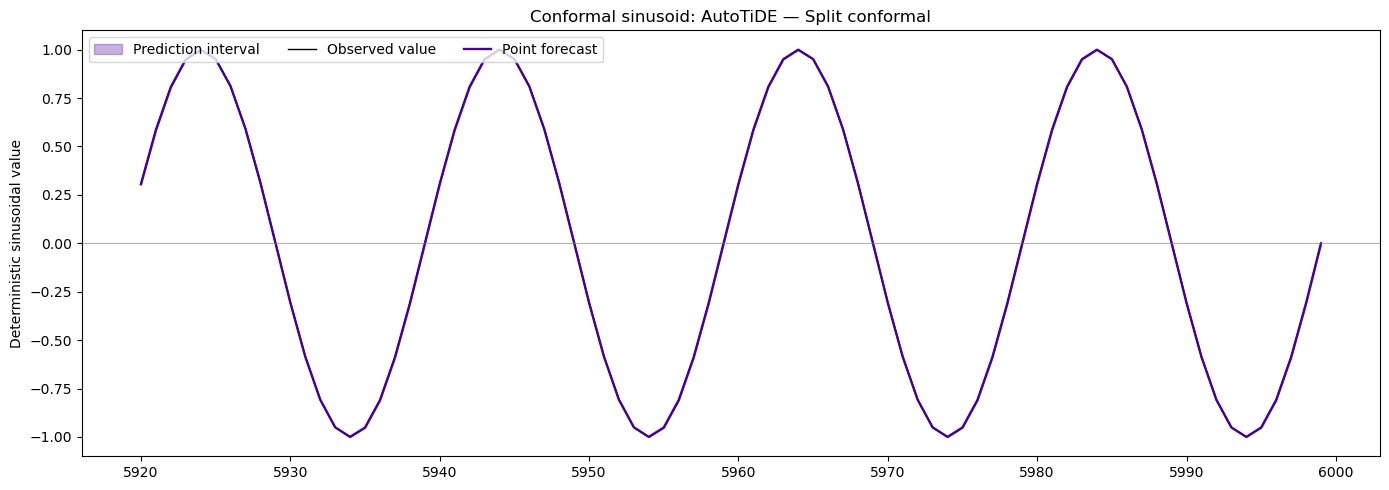

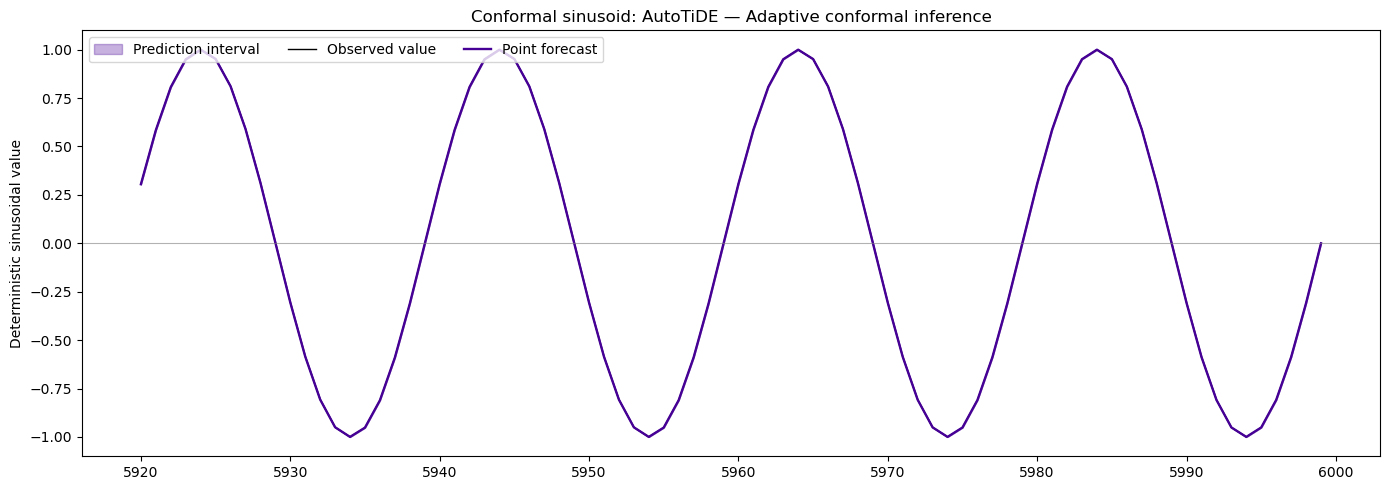

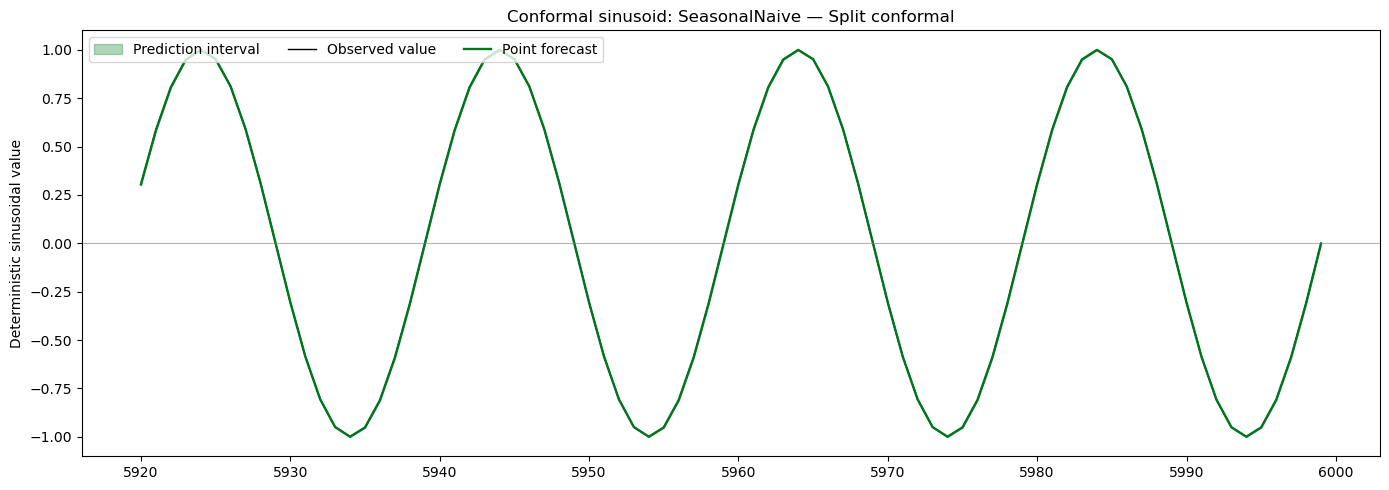

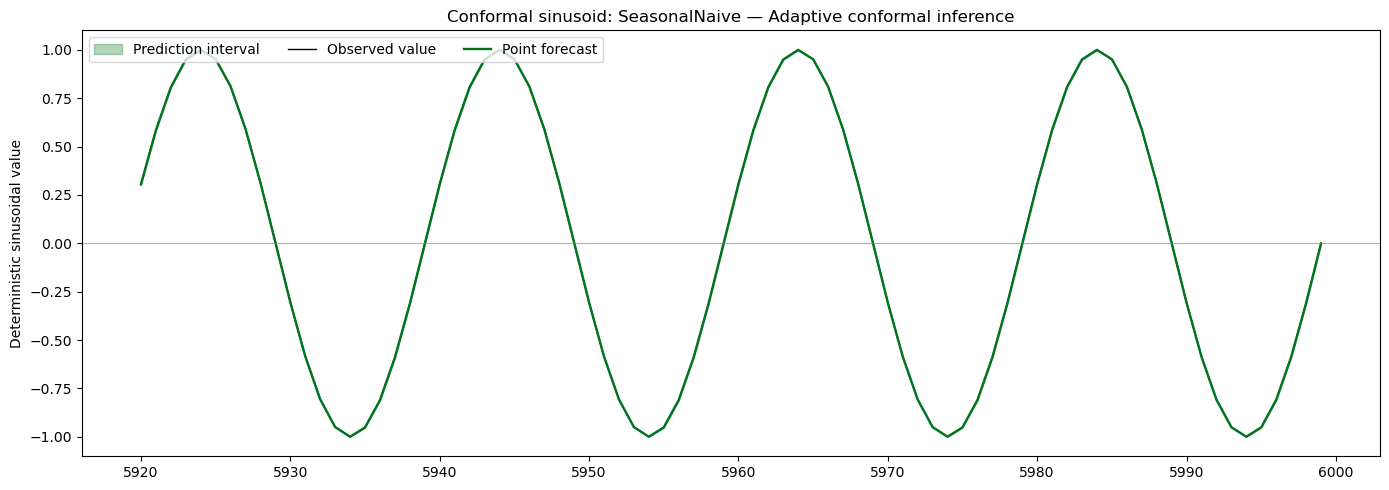

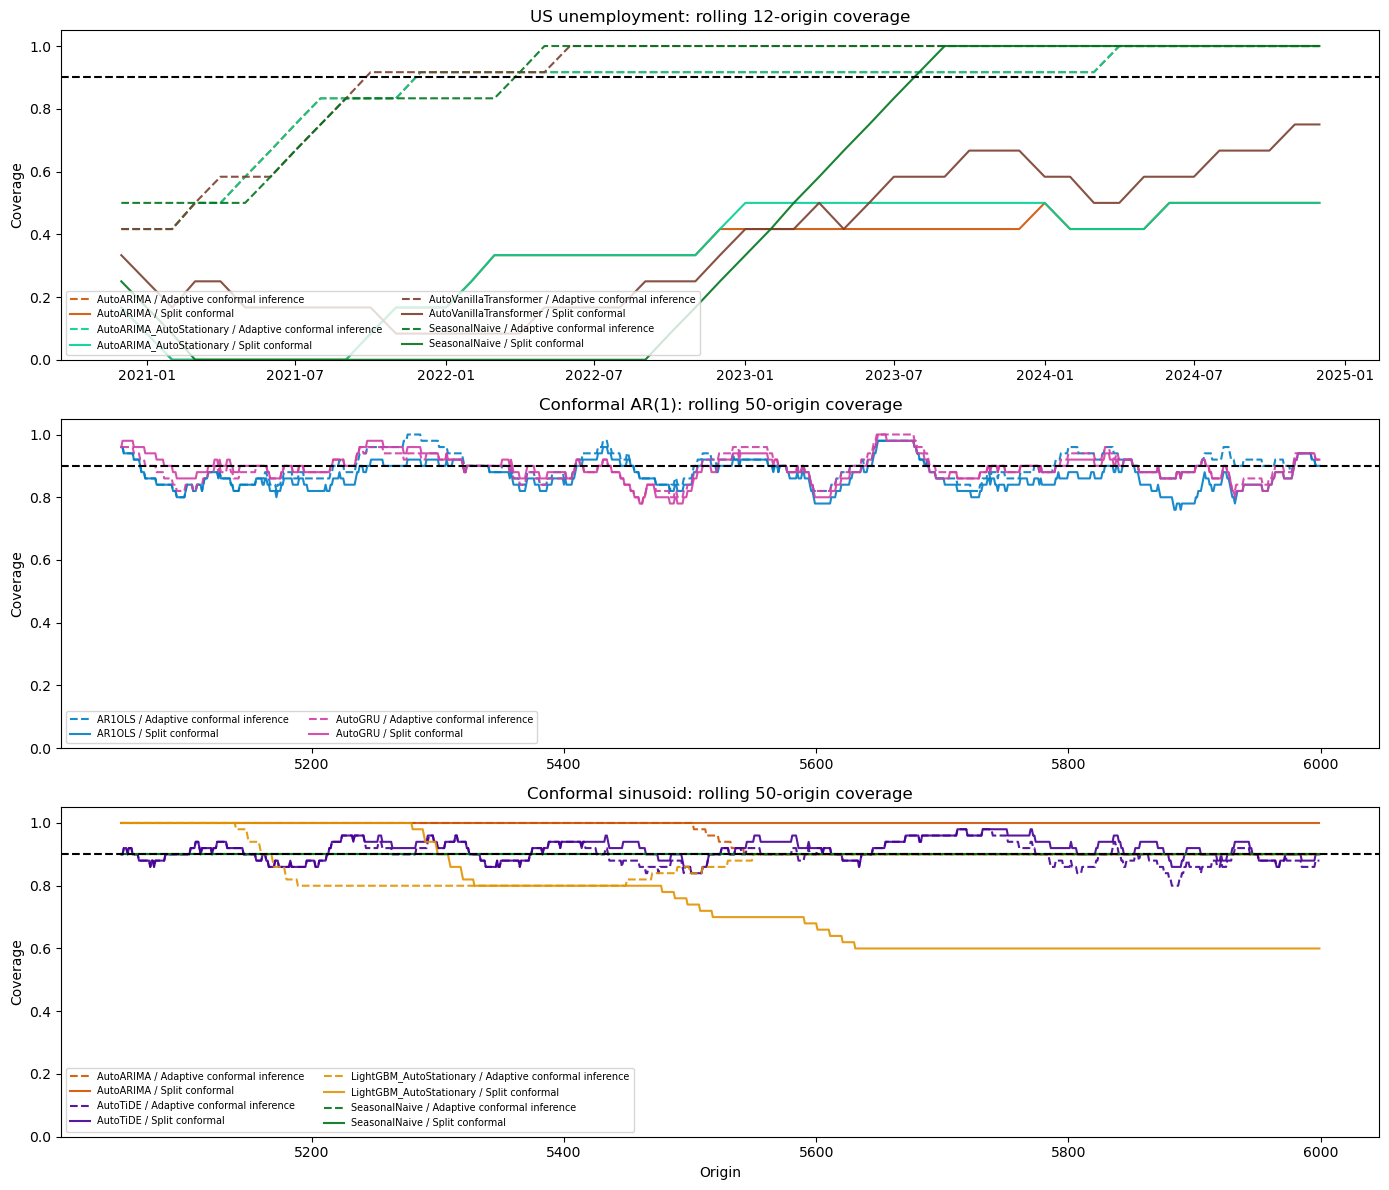

In [10]:
if 'interval_forecasts' not in globals():
    interval_forecasts = pd.read_csv(
        RESULTS_DIR / 'predictable_conformal_intervals.csv'
    )

all_interval_models = sorted(interval_forecasts['Model'].dropna().unique())
model_palette = [
    "#007EC7", "#CF5300", "#00D095", "#D03FA5", "#460096",
    '#7A3E2F', "#E19300", "#00751D", "#4C4C4C", "#790016",
    "#003892", "#ED0000",
]
MODEL_COLORS = {
    model: model_palette[index % len(model_palette)]
    for index, model in enumerate(all_interval_models)
}
METHOD_LINESTYLES = {
    'Split conformal': '-',
    'Online fixed-alpha': ':',
    'Adaptive conformal inference': '--',
}

for dataset in dataset_partitions:
    subset = interval_forecasts[interval_forecasts['Dataset'] == dataset]
    setting = dataset_settings[dataset]
    is_unemployment = dataset == 'US unemployment'
    for model in subset['Model'].drop_duplicates():
        for method in ('Split conformal', 'Online fixed-alpha', 'Adaptive conformal inference'):
            fig = plot_interval_forecast(
                subset, model, method=method,
                tail=setting['plot_tail'],
                y_label=metadata_for(setting['metadata_key'])['y_axis_label'],
                observed_label='Observed value',
                zero_line=not is_unemployment,
            )
            axis = fig.axes[0]
            for line in axis.get_lines():
                if line.get_label() == 'Point forecast':
                    line.set_color(MODEL_COLORS[model])
                    line.set_linewidth(1.7)
            for collection in axis.collections:
                if collection.get_label() == 'Prediction interval':
                    collection.set_facecolor(MODEL_COLORS[model])
                    collection.set_edgecolor(MODEL_COLORS[model])
                    collection.set_alpha(0.30)
            axis.legend(loc='upper left', ncol=3)
            display_method = 'Fixed residual quantile' if method == 'Split conformal' else method
            axis.set_title(f'{dataset}: {model} — {display_method}')
            save_matplotlib_figure(
                fig,
                figure_path(
                    'predictable_series_conformal', setting['metadata_key'], model, method,
                    extension=FIGURE_FORMAT,
                ),
                SAVE_FIGURES,
            )
            plt.show()
            plt.close(fig)

fig, axes = plt.subplots(
    len(dataset_partitions), 1,
    figsize=(14, 4 * len(dataset_partitions)), squeeze=False,
)
for axis, dataset in zip(axes[:, 0], dataset_partitions):
    window = 12 if dataset == 'US unemployment' else 50
    subset = interval_forecasts[interval_forecasts['Dataset'] == dataset]
    for (model, method), group in subset.groupby(['Model', 'Method']):
        group = group.sort_values('ds')
        covered = group['y'].between(group['lower'], group['upper']).astype(float)
        axis.plot(
            group['date'], covered.rolling(window, min_periods=window).mean(),
            label=f'{model} / {method}', color=MODEL_COLORS[model],
            linestyle=METHOD_LINESTYLES[method], alpha=0.90,
        )
    axis.axhline(INTERVAL_LEVEL / 100, color='black', linestyle='--')
    axis.set(title=f'{dataset}: rolling {window}-origin coverage', ylabel='Coverage')
    axis.set_ylim(0, 1.05)
    axis.legend(loc='lower left', fontsize=7, ncol=2)
axes[-1, 0].set_xlabel('Origin')
fig.tight_layout()
save_matplotlib_figure(
    fig,
    figure_path(
        'predictable_series_conformal', 'unemployment_us', 'three_dataset_coverage_comparison',
        extension=FIGURE_FORMAT,
    ),
    SAVE_FIGURES,
)
plt.show()
plt.close(fig)

## Interpretation guardrails

- The long AR(1) has stable coefficient 0.5, zero initialization, and constant Gaussian innovation variance throughout training, validation, calibration, and test. Its initialization transient rapidly vanishes; no regime change is introduced.
- The long sinusoid has amplitude 1 and TimeSynth frequency 0.25. As in the Chapter 1 example, it is sampled five times per TimeSynth time unit, giving approximately 20 observations per cycle. It has no stochastic innovation or regime change.
- The 60 unemployment and 1,000 test origins for each synthetic process improve coverage estimation; they do not change the one-step forecast horizon.
- AutoStationary is used by tree models for US unemployment and the deterministic sinusoid. It is fitted inside every ML fold and again on the fitting history available at each external stage. Forecasts are inverted before selection or conformal scoring.
- The stable AR(1) is evaluated only on its original target. The sinusoid retains Original classical/DL candidates but uses one deseasonalized tree representation rather than duplicating both representations within every family.
- DL models use the original target, matching the main deep-learning notebook.
- Validation selects configurations. Calibration estimates nonconformity scores. The online fixed-alpha benchmark expands the score history while keeping alpha at 0.10, separating that update from ACI's adaptive alpha. Test outcomes cannot replace the selected model and enter either online procedure only after their own intervals have been issued.